<a href="https://colab.research.google.com/github/Gayathri2526/AIML-learning-Projects/blob/main/Diabetes-Prediction/Diabetes_Prediction_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction - Classification Models

## 1. Load and Understand the Dataset

In [1]:
import pandas as pd

# Load the diabetes dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

# Display first 5 rows
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Explore the Dataset

In [2]:
# Check dataset size
print("Dataset shape:", df.shape)

# Check column information
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check target class distribution
print("\nDiabetes class distribution:")
print(df["diabetes"].value_counts())

Dataset shape: (100000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0

## 3. Prepare Features and Target

In [3]:
# Separate input features and target

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Check categorical columns
print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns)

Features shape: (100000, 8)
Target shape: (100000,)

Categorical columns:
Index(['gender', 'smoking_history'], dtype='object')


## 4. Encode Categorical Features

In [4]:
# Convert categorical columns into numeric columns using one-hot encoding

X = pd.get_dummies(
    X,
    columns=["gender", "smoking_history"],
    drop_first=True
)

print("Shape after encoding:", X.shape)
print("\nColumns after encoding:")
print(X.columns)

Shape after encoding: (100000, 13)

Columns after encoding:
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


## 5. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (80000, 13)
X_test shape: (20000, 13)

Training target distribution:
diabetes
0    73200
1     6800
Name: count, dtype: int64

Testing target distribution:
diabetes
0    18300
1     1700
Name: count, dtype: int64


## 6. Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for test data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (80000, 13)
Testing data shape: (20000, 13)


## 7. Logistic Regression Model

In [7]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 8. Logistic Regression Evaluation

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calculate evaluation metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

# Get probability predictions for ROC-AUC
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
log_roc_auc = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Results")
print("Accuracy :", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall   :", round(log_recall, 4))
print("F1 Score :", round(log_f1, 4))
print("ROC-AUC  :", round(log_roc_auc, 4))

Logistic Regression Results
Accuracy : 0.9605
Precision: 0.8594
Recall   : 0.64
F1 Score : 0.7336
ROC-AUC  : 0.9625


## 9. Decision Tree Model

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## 10. Decision Tree Evaluation

In [10]:
# Calculate evaluation metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

# Probability predictions for ROC-AUC
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]
tree_roc_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))
print("ROC-AUC  :", round(tree_roc_auc, 4))

Decision Tree Results
Accuracy : 0.9723
Precision: 1.0
Recall   : 0.6741
F1 Score : 0.8053
ROC-AUC  : 0.9541


## 11. Random Forest Model

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 12. Random Forest Evaluation

In [12]:
# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Get probability predictions for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
Accuracy : 0.9703
Precision: 0.9474
Recall   : 0.6888
F1 Score : 0.7977
ROC-AUC  : 0.9616


## 13. Model Comparison

In [13]:
# Create comparison table for all three models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        tree_recall,
        rf_recall
    ],
    "F1 Score": [
        log_f1,
        tree_f1,
        rf_f1
    ],
    "ROC-AUC": [
        log_roc_auc,
        tree_roc_auc,
        rf_roc_auc
    ]
})

# Round values for readability
results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9605,0.8594,0.6400,0.7336,0.9625
1,Decision Tree,0.9723,1.0000,0.6741,0.8053,0.9541
2,Random Forest,0.9703,0.9474,0.6888,0.7977,0.9616


## 14. Confusion Matrix - Best Model

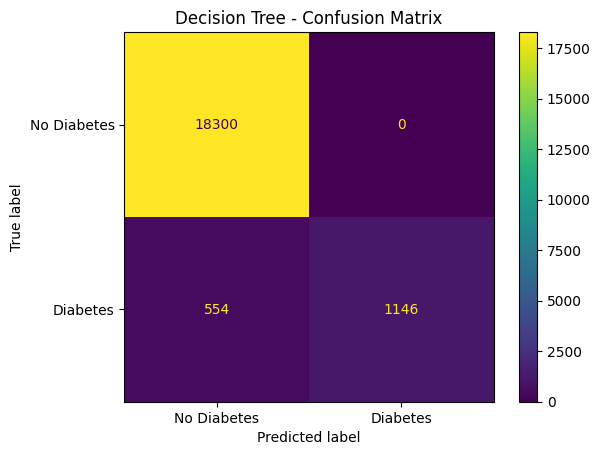

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix for Decision Tree
cm = confusion_matrix(y_test, y_pred_tree)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

## 15. Best Model Selection

The Decision Tree was selected as the best model because it achieved the highest accuracy (97.23%) and F1-score (80.53%) among the three models. It also achieved 100% precision, meaning that all patients predicted as diabetic were actually diabetic. Therefore, the Decision Tree provides the best overall performance among the models tested.